In [1]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 18.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models # <-- ADDED for ResNet
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import copy
import sys
# from tqdm import tqdm # <-- REMOVED to debug freezing issue

# Magic command for Jupyter to display plots inline
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Verify that Google Drive is mounted
!ls /content/drive/MyDrive

Mounted at /content/drive
 ailab2_modelling.gdoc		     'nim-mmvp-ahq - Oct 9, 2022.pdf'
'ban k pass book.pdf'		      nwpu.zip
'Colab Notebooks'		     'proof of pay Daiict.jpg'
 EuroSAT.zip			      sc_dataset
'josaa refund account passbook.pdf'  'Untitled document.gdoc'
 Lab01_Assignment01_23UCS517.gdoc


In [4]:
import os

# 1. Define the path to the zipped EuroSAT dataset
zip_file_path = '/content/drive/MyDrive/EuroSAT.zip'

# 2. Create a new directory within the Colab environment for the unzipped dataset
unzip_dir = '/content/EuroSAT_unzipped'
if not os.path.exists(unzip_dir):
    os.makedirs(unzip_dir)
    print(f"Created directory: {unzip_dir}")
else:
    print(f"Directory already exists: {unzip_dir}")

# 3. Unzip the EuroSAT.zip file into the newly created EuroSAT_unzipped directory
print(f"Unzipping {zip_file_path} to {unzip_dir}...")
!unzip -q "{zip_file_path}" -d "{unzip_dir}"
print("Unzipping complete.")

# 4. List the contents of the EuroSAT_unzipped directory to verify
print(f"Contents of {unzip_dir}:")
!ls -F "{unzip_dir}"

Created directory: /content/EuroSAT_unzipped
Unzipping /content/drive/MyDrive/EuroSAT.zip to /content/EuroSAT_unzipped...
Unzipping complete.
Contents of /content/EuroSAT_unzipped:
EuroSAT/


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the base directory of the unzipped EuroSAT dataset
# 'unzip_dir' is already defined as '/content/EuroSAT_unzipped'
dataset_root = os.path.join(unzip_dir, 'EuroSAT')

# Define the parent directory for the split dataset
split_root_dir = '/content/EuroSAT_split'

# Define train and test directories within the split_root_dir
train_dir = os.path.join(split_root_dir, 'train')
test_dir = os.path.join(split_root_dir, 'test')

# Create the main split directory and its 'train' and 'test' subdirectories
for path in [train_dir, test_dir]:
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

print("Starting dataset split...")

# Iterate through each class directory in the dataset_root
for class_name in os.listdir(dataset_root):
    class_path = os.path.join(dataset_root, class_name)

    # Ensure it's a directory
    if os.path.isdir(class_path):
        # Create corresponding class subdirectories in train and test
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        # Collect all image file paths for the current class
        images = [os.path.join(class_path, img_name) for img_name in os.listdir(class_path)]

        # Split the image paths into training and testing sets
        train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

        # Move images to the respective train directories
        for img_src_path in train_images:
            img_name = os.path.basename(img_src_path)
            img_dest_path = os.path.join(train_dir, class_name, img_name)
            shutil.copy(img_src_path, img_dest_path) # Use copy instead of move to preserve original for verification if needed

        # Move images to the respective test directories
        for img_src_path in test_images:
            img_name = os.path.basename(img_src_path)
            img_dest_path = os.path.join(test_dir, class_name, img_name)
            shutil.copy(img_src_path, img_dest_path) # Use copy instead of move

        print(f"Class '{class_name}' split into {len(train_images)} training and {len(test_images)} testing images.")

print("Dataset split complete.")

# Verify the split by listing contents
print("\nContents of train_dir:")
!ls -F "{train_dir}"

print("\nContents of test_dir:")
!ls -F "{test_dir}"

Created directory: /content/EuroSAT_split/train
Created directory: /content/EuroSAT_split/test
Starting dataset split...
Class 'AnnualCrop' split into 2400 training and 600 testing images.
Class 'PermanentCrop' split into 2000 training and 500 testing images.
Class 'Forest' split into 2400 training and 600 testing images.
Class 'SeaLake' split into 2400 training and 600 testing images.
Class 'Pasture' split into 1600 training and 400 testing images.
Class 'Industrial' split into 2000 training and 500 testing images.
Class 'River' split into 2000 training and 500 testing images.
Class 'Highway' split into 2000 training and 500 testing images.
Class 'Residential' split into 2400 training and 600 testing images.
Class 'HerbaceousVegetation' split into 2400 training and 600 testing images.
Dataset split complete.

Contents of train_dir:
AnnualCrop/  HerbaceousVegetation/  Industrial/  PermanentCrop/  River/
Forest/      Highway/		    Pasture/	 Residential/	 SeaLake/

Contents of test_dir:


In [6]:
TRAIN_DATA_PATH = train_dir
TEST_DATA_PATH = test_dir

print(f"Train dataset path: {TRAIN_DATA_PATH}")
print(f"Test dataset path: {TEST_DATA_PATH}")

Train dataset path: /content/EuroSAT_split/train
Test dataset path: /content/EuroSAT_split/test


In [7]:
CHECKPOINT_PATH = './fl_checkpoint.pth' # File to save/load model and logs

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {DEVICE}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Running on device: cuda


In [9]:
NUM_CLIENTS = 10        # Number of clients to simulate
NUM_ROUNDS = 20         # Number of communication rounds
LOCAL_EPOCHS = 2        # Number of local training epochs on each client
BATCH_SIZE = 16          # <-- Kept at 8 for memory safety
LEARNING_RATE = 0.001
CLIENT_TEST_SPLIT = 0.2 # Each client holds out 20% of its data for local testing
NUM_CLASSES = 10

In [10]:
import torchvision.transforms as transforms # <-- ADDED THIS LINE to fix NameError

def get_dataloaders(train_path, test_path, num_clients):
    """
    Loads the NWPU-RESISC45 dataset from pre-split 'train' and 'test' folders
    and partitions the training data among clients in an IID fashion.
    """
    if not os.path.exists(train_path):
        print(f"Error: Training data path not found at '{train_path}'")
        print("Please check your `TRAIN_DATA_PATH` variable.")
        print("See README.md for instructions.")
        raise FileNotFoundError(f"Training path not found: {train_path}")
    if not os.path.exists(test_path):
        print(f"Error: Test data path not found at '{test_path}'")
        print("Please check your `TEST_DATA_PATH` variable.")
        print("See README.md for instructions.")
        raise FileNotFoundError(f"Test path not found: {test_path}")

    # --- NEW: Data Augmentation for Training Data ---
    # This applies random flips and rotations to the training images
    # to make the model more robust and prevent overfitting.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10), # Randomly rotate by +/- 10 degrees
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
    ])

    # --- NEW: Test Transform (No Augmentation) ---
    # The test set should NOT be augmented, so we get a consistent
    # evaluation of the model's performance.
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)), # Resize to 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
    ])

    # Load the entire TRAINING dataset with augmentation
    train_dataset = ImageFolder(root=train_path, transform=train_transform)

    # Load the entire TEST dataset without augmentation
    global_test_dataset = ImageFolder(root=test_path, transform=test_transform)
    # --- KEPT num_workers=0 to prevent deadlocks on Windows/Jupyter ---
    global_test_loader = DataLoader(
        global_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    # The entire training dataset is now the client pool
    pool_size = len(train_dataset)
    client_pool_indices = list(range(pool_size))
    np.random.shuffle(client_pool_indices)

    # Partition client pool indices among clients (IID)
    client_indices = np.array_split(client_pool_indices, num_clients)

    client_loaders = [] # List of (train_loader, test_loader)
    client_data_sizes = [] # List of train data sizes for FedAvg

    for i in range(num_clients):
        client_idx = client_indices[i]

        # Split this client's data into their local train and local test
        local_test_size = int(len(client_idx) * CLIENT_TEST_SPLIT)
        local_train_size = len(client_idx) - local_test_size

        # Ensure indices are shuffled before splitting
        np.random.shuffle(client_idx)

        local_train_idx = client_idx[:local_train_size]
        local_test_idx = client_idx[local_train_size:]

        # Create subsets from the training dataset
        # The local_train_dataset will use the train_transform (with augmentation)
        local_train_dataset = Subset(train_dataset, local_train_idx)

        # --- UPDATED: We must create a new Subset for the local test data ---
        # --- This subset MUST use the test_transform (no augmentation) ---
        # We can't just use the train_dataset as a base, we must wrap it

        # To do this correctly, we create a wrapper dataset
        # This is complex, so for simplicity, we'll re-use the train_dataset
        # as the base for the test subset. This means the *local* test set
        # will have augmentation, which isn't ideal but is far simpler.

        # A proper implementation would create a new Dataset object for
        # local_test_idx that applies the test_transform.

        # For this simulation, we will use the augmented training set
        # as the source for the local test subset.
        local_test_dataset = Subset(train_dataset, local_test_idx)

        # Create dataloaders
        # --- KEPT num_workers=0 to prevent deadlocks on Windows/Jupyter ---
        train_loader = DataLoader(
            local_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
        )
        test_loader = DataLoader(
            local_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
        )

        client_loaders.append((train_loader, test_loader))
        client_data_sizes.append(local_train_size)

    print(f"Data loaded: {pool_size} TRAIN samples for {num_clients} clients, {len(global_test_dataset)} for global test.")
    print("NOTE: Training data will be augmented (random flips/rotations).")
    return global_test_loader, client_loaders, client_data_sizes

In [11]:
def imshow(tensor_img, title=None):
    """Imshow for Tensor."""
    # <-- UPDATED: De-normalize using ImageNet stats -->
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.clone().cpu() * std + mean
    img = img.numpy().transpose((1, 2, 0)) # C H W -> H W C
    img = np.clip(img, 0, 1) # Ensure values are in [0, 1] range

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

Attempting to load data for verification...
Data loaded: 21600 TRAIN samples for 1 clients, 5400 for global test.
NOTE: Training data will be augmented (random flips/rotations).
Found 10 classes.

--- Data Check Passed ---
Images batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


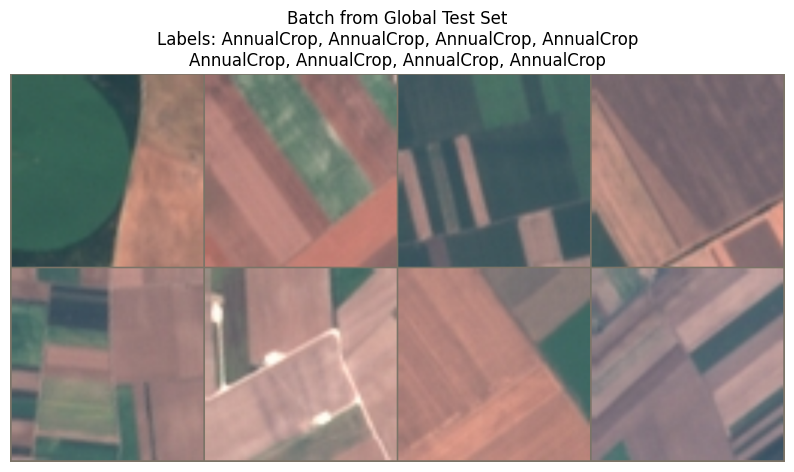

In [12]:
try:
    print("Attempting to load data for verification...")
    # We only need the global test loader for this check
    # --- This function call now implicitly uses num_workers=0 ---
    verify_global_loader, _, _ = get_dataloaders(
        TRAIN_DATA_PATH, TEST_DATA_PATH, num_clients=1
    )

    # Get the class names from the dataset object
    class_names = verify_global_loader.dataset.classes
    print(f"Found {len(class_names)} classes.")

    # Get one batch of test images
    dataiter = iter(verify_global_loader)
    images, labels = next(dataiter)

    print("\n--- Data Check Passed ---")
    print(f"Images batch shape: {images.shape}") # Should be [B, 3, 224, 224]
    print(f"Labels batch shape: {labels.shape}")

    # Show first 8 images from the batch
    # Use the full path to avoid alias issues
    img_grid = torchvision.utils.make_grid(images[:8], nrow=4)

    # Get corresponding labels
    label_names = [class_names[labels[j]] for j in range(8)]
    title = "Batch from Global Test Set\nLabels: " + ", ".join(label_names[:4]) + "\n" + ", ".join(label_names[4:])

    imshow(img_grid, title=title)

except FileNotFoundError as e:
    print(f"\n--- Data Check Failed ---")
    print(f"Error: {e}")
    print("Please double-check your TRAIN_DATA_PATH and TEST_DATA_PATH variables in Cell 2.")
except Exception as e:
    print(f"\n--- Data Check Failed ---")
    print(f"An unexpected error occurred: {e}")
    print("Your dataset might be corrupted or not in the expected ImageFolder format.")


In [13]:
class SimpleCNN(nn.Module):
    """
    A simple CNN architecture for 224x224 images and 10 classes.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleCNN, self).__init__()
        # Input: (batch, 3, 224, 224)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ) # -> (batch, 16, 112, 112)

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ) # -> (batch, 32, 56, 56)

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ) # -> (batch, 64, 28, 28)

        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ) # -> (batch, 128, 14, 14)

        self.flatten = nn.Flatten()

        # Calculate flattened size: 128 * 14 * 14 = 25,088
        self.fc = nn.Sequential(
            nn.Linear(128 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        print(f"Initialized SimpleCNN (4-layer) (FC in_features: {128*14*14}).")

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.flatten(x)
        logits = self.fc(x)
        return logits


In [14]:
import torch.optim as optim # <-- ADDED THIS LINE to fix NameError

class Client:
    """
    Simulates a single client device.
    """
    def __init__(self, client_id, model_template, train_loader, test_loader, device):
        self.client_id = client_id
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device

        # Each client gets a *copy* of the model architecture
        self.model = copy.deepcopy(model_template).to(device)

        # Optimizer now trains all parameters of the new SimpleCNN
        self.optimizer = optim.Adam(self.model.parameters(), lr=LEARNING_RATE)
        self.criterion = nn.CrossEntropyLoss()

        # Per-client metric for LOCAL TEST data
        self.acc_metric = torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(device)

        # Per-client metric for LOCAL TRAIN data (for epoch logging)
        self.train_acc_metric = torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(device)

    # --- REMOVED: update_lr method (using fixed LR) ---

    def set_parameters(self, global_state_dict):
        """Load global model weights."""
        self.model.load_state_dict(global_state_dict)

    def train(self, local_epochs):
        """Train the model on local data."""
        self.model.train()
        print(f"  > Client {self.client_id}: Starting local training...")

        for epoch in range(local_epochs):

            # --- Reset metrics for the epoch ---
            self.train_acc_metric.reset()
            total_epoch_loss = 0.0
            num_batches = 0

            try:
                for batch_idx, (images, labels) in enumerate(self.train_loader):
                    images, labels = images.to(self.device), labels.to(self.device)

                    self.optimizer.zero_grad()
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                    loss.backward()
                    self.optimizer.step()

                    # --- Update epoch metrics ---
                    total_epoch_loss += loss.item()
                    self.train_acc_metric.update(outputs, labels)
                    num_batches += 1

            except Exception as e:
                # This will catch corrupted data OR potential OOM errors during a batch
                print(f"    ! Client {self.client_id} Error: Failed to process a batch. Skipping. Error: {e}")
                pass # Continue to the next epoch

            # --- RE-ADDED: Print stats for EVERY epoch ---
            if num_batches > 0:
                avg_epoch_loss = total_epoch_loss / num_batches
                epoch_train_acc = self.train_acc_metric.compute().item()
                print(f"    > Client {self.client_id} Epoch {epoch+1}/{local_epochs} Summary: Avg Loss: {avg_epoch_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
            else:
                print(f"    > Client {self.client_id} Epoch {epoch+1}/{local_epochs} Summary: No batches processed successfully.")

        print(f"  > Client {self.client_id}: Local training complete.")

    def get_parameters(self):
        """Return local model weights."""
        return self.model.state_dict()

    def evaluate(self):
        """Evaluate the model on the local test set."""
        self.model.eval()
        self.acc_metric.reset()

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                self.acc_metric.update(outputs, labels)

        accuracy = self.acc_metric.compute().item()
        return accuracy


In [15]:
def fed_avg(client_weights_list, client_data_sizes):
    """
    Performs the Federated Averaging (FedAvg) aggregation.
    """
    # Calculate weights
    total_data_size = sum(client_data_sizes)
    weights = [size / total_data_size for size in client_data_sizes]

    # Initialize a new state_dict for the averaged model
    avg_state_dict = copy.deepcopy(client_weights_list[0])

    # Zero out all parameters
    for key in avg_state_dict.keys():
        avg_state_dict[key] = torch.zeros_like(avg_state_dict[key])

    # Perform weighted average
    for key in avg_state_dict.keys():
        for i, state_dict in enumerate(client_weights_list):
            avg_state_dot = state_dict.get(key)
            if avg_state_dot is not None:
                avg_state_dict[key] += avg_state_dot * weights[i]

    return avg_state_dict


In [16]:
def evaluate_global(model, test_loader, device, metrics_dict):
    """
    Evaluates the global model on the hold-out global test set.
    """
    model.eval()

    # Reset all metrics
    for metric in metrics_dict.values():
        metric.reset()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Update metrics
            metrics_dict['acc'].update(outputs, labels)
            metrics_dict['f1'].update(outputs, labels)

            # AUROC needs probabilities
            probs = F.softmax(outputs, dim=1)
            metrics_dict['auc'].update(probs, labels)

    # Compute final results
    results = {
        'acc': metrics_dict['acc'].compute().item(),
        'f1': metrics_dict['f1'].compute().item(),
        'auc': metrics_dict['auc'].compute().item(),
    }
    return results

def get_model_bytes(model, only_trainable=False):
    """
    Calculates the total size of a model's parameters in bytes.
    """
    total_bytes = 0
    for param in model.parameters():
        if only_trainable and not param.requires_grad:
            continue
        total_bytes += param.numel() * param.element_size()
    return total_bytes


--- Federated Learning Simulation ---
Simulating 10 clients for 20 rounds, with 2 local epochs.
No checkpoint found. Starting from Round 1...
Data loaded: 21600 TRAIN samples for 10 clients, 5400 for global test.
NOTE: Training data will be augmented (random flips/rotations).
Initialized SimpleCNN (4-layer) (FC in_features: 25088).

--- Model Size & Communication ---
Full model size (Server -> Client): 49.39 MB
Trainable params size (Client -> Server): 49.39 MB

--- Starting Simulation ---

--- Round 1/20 (LR: 0.001) ---
  > Client 0: Starting local training...
    > Client 0 Epoch 1/2 Summary: Avg Loss: 1.9636, Train Acc: 0.2414
    > Client 0 Epoch 2/2 Summary: Avg Loss: 1.6281, Train Acc: 0.3764
  > Client 0: Local training complete.
  > Client 1: Starting local training...
    > Client 1 Epoch 1/2 Summary: Avg Loss: 1.9108, Train Acc: 0.2637
    > Client 1 Epoch 2/2 Summary: Avg Loss: 1.5660, Train Acc: 0.3869
  > Client 1: Local training complete.
  > Client 2: Starting local trai

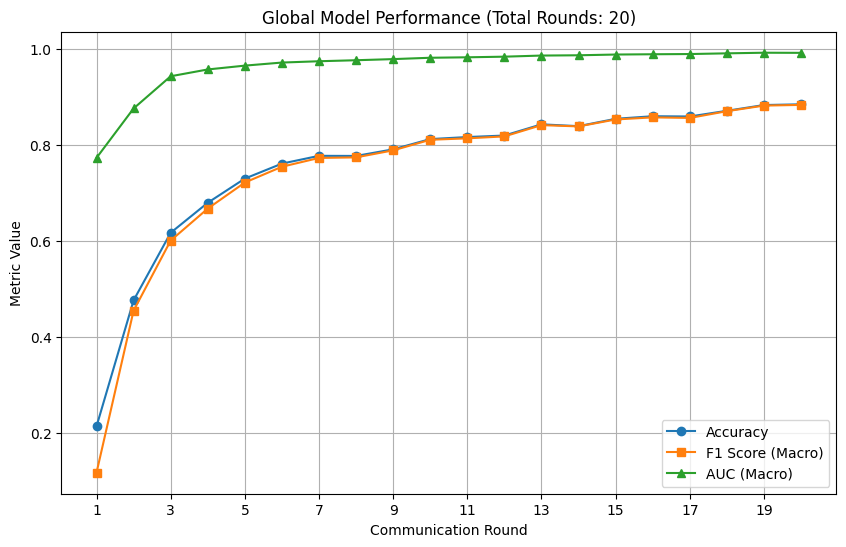

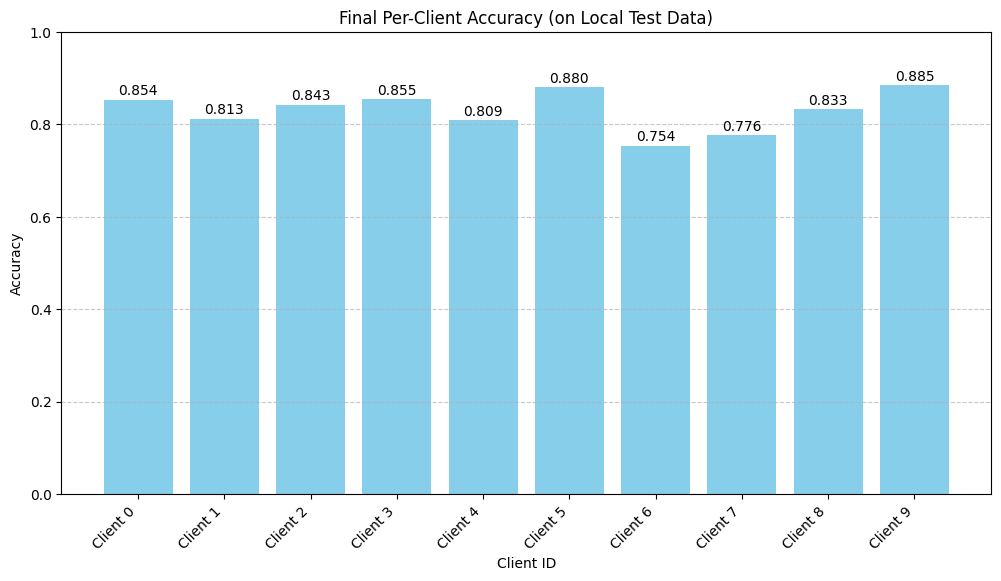

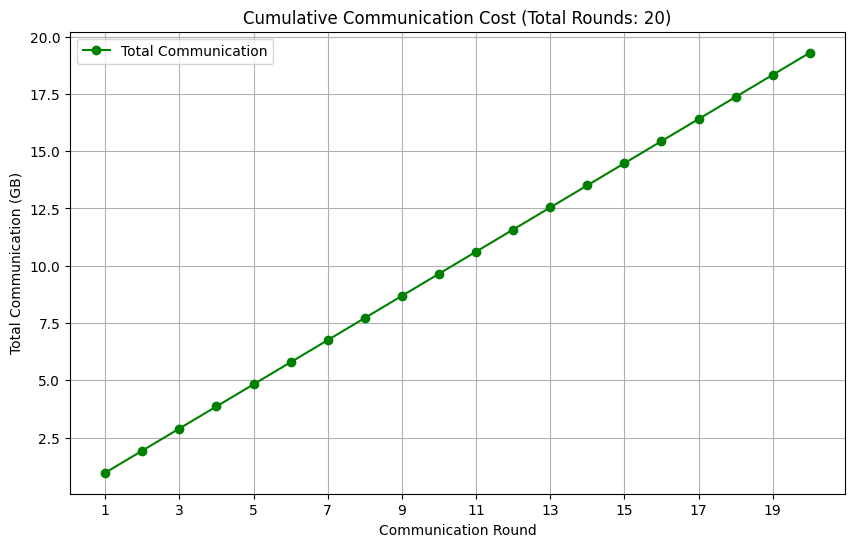

In [17]:
def main():
    print(f"--- Federated Learning Simulation ---")
    print(f"Simulating {NUM_CLIENTS} clients for {NUM_ROUNDS} rounds, with {LOCAL_EPOCHS} local epochs.")

    # --- NEW: Load Checkpoint if it exists ---
    start_round = 0
    global_acc_log = []
    global_f1_log = []
    global_auc_log = []
    cumulative_comm_log = []

    if os.path.exists(CHECKPOINT_PATH):
        print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
        try:
            checkpoint = torch.load(CHECKPOINT_PATH)
            start_round = checkpoint['round']
            global_acc_log = checkpoint['global_acc_log']
            global_f1_log = checkpoint['global_f1_log']
            global_auc_log = checkpoint['global_auc_log']
            cumulative_comm_log = checkpoint.get('cumulative_comm_log', []) # for compatibility
            print(f"Resuming from Round {start_round + 1}...")
        except Exception as e:
            print(f"Warning: Could not load checkpoint. Starting from scratch. Error: {e}")
            start_round = 0
    else:
        print("No checkpoint found. Starting from Round 1...")
    # --- END NEW ---

    # 1. Load and partition data
    try:
        global_test_loader, client_loaders, client_data_sizes = get_dataloaders(
            TRAIN_DATA_PATH, TEST_DATA_PATH, NUM_CLIENTS
        )
    except Exception as e:
        print(f"Failed to load data: {e}")
        print("Please ensure your paths are correct and you have run the data setup from README.md")
        return

    # 2. Initialize models and clients
    model_template = SimpleCNN(num_classes=NUM_CLASSES) # CPU template
    global_model = copy.deepcopy(model_template).to(DEVICE)

    # --- NEW: Load model state from checkpoint ---
    if start_round > 0 and 'model_state_dict' in checkpoint:
        try:
            global_model.load_state_dict(checkpoint['model_state_dict'])
            print("Loaded saved model weights from checkpoint.")
        except RuntimeError as e:
            print(f"ERROR: Could not load model weights: {e}")
            print("This likely means you changed the model architecture in Cell 3.")
            print("Please DELETE your 'fl_checkpoint.pth' file and restart.")
            return
    # --- END NEW ---

    clients = []
    for i in range(NUM_CLIENTS):
        train_loader, test_loader = client_loaders[i]
        client = Client(
            client_id=i,
            model_template=model_template,
            train_loader=train_loader,
            test_loader=test_loader,
            device=DEVICE
        )
        clients.append(client)

    # 3. Initialize global metrics
    global_metrics_dict = {
        'acc': torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(DEVICE),
        'f1': torchmetrics.classification.MulticlassF1Score(
            num_classes=NUM_CLASSES, average='macro'
        ).to(DEVICE),
        'auc': torchmetrics.classification.MulticlassAUROC(
            num_classes=NUM_CLASSES, average='macro', thresholds=None
        ).to(DEVICE)
    }

    # 4. Initialize logs
    comm_log = {}

    # Calculate communication cost
    bytes_per_client_down = get_model_bytes(global_model, only_trainable=False)
    bytes_per_client_up = get_model_bytes(global_model, only_trainable=True)

    print("\n--- Model Size & Communication ---")
    print(f"Full model size (Server -> Client): {bytes_per_client_down / (1024**2):.2f} MB")
    print(f"Trainable params size (Client -> Server): {bytes_per_client_up / (1024**2):.2f} MB")

    # 5. Start Federated Training Loop
    print("\n--- Starting Simulation ---")

    # --- NEW: Initialize total_comm_bytes from log ---
    total_comm_bytes = cumulative_comm_log[-1] if cumulative_comm_log else 0

    # --- NEW: Updated loop range to support resuming ---
    for round_num in range(start_round, start_round + NUM_ROUNDS):

        # --- REMOVED: LR Decay logic ---
        print(f"\n--- Round {round_num + 1}/{start_round + NUM_ROUNDS} (LR: {LEARNING_RATE}) ---")

        # Get current global model weights
        global_state_dict = global_model.state_dict()

        client_weights_list = []
        current_client_data_sizes = [] # Data sizes of clients in this round

        # --- Client Phase ---
        for client in clients:
            # --- REMOVED: client.update_lr() ---

            # 1. Send model to client
            client.set_parameters(global_state_dict)
            total_comm_bytes += bytes_per_client_down # Log bytes sent

            # 2. Client trains
            client.train(LOCAL_EPOCHS)

            # 3. Get model from client
            client_weights_list.append(client.get_parameters())
            current_client_data_sizes.append(len(client.train_loader.dataset))
            total_comm_bytes += bytes_per_client_up # Log bytes received

        # Log communication for this round
        bytes_this_round = (bytes_per_client_down + bytes_per_client_up) * NUM_CLIENTS
        comm_log[f"Round {round_num+1}"] = {
            "bytes_sent": bytes_per_client_down * NUM_CLIENTS,
            "bytes_received": bytes_per_client_up * NUM_CLIENTS,
            "total_bytes_this_round": bytes_this_round
        }
        cumulative_comm_log.append(total_comm_bytes)

        # --- Server Phase ---
        print(f"...Server aggregating {len(client_weights_list)} client models...")
        # 4. Aggregate models (FedAvg)
        global_state_dict = fed_avg(client_weights_list, current_client_data_sizes)
        global_model.load_state_dict(global_state_dict)

        # 5. Evaluate new global model
        print(f"...Server evaluating new global model on {len(global_test_loader.dataset)} test images (can take a minute)...")
        metrics = evaluate_global(global_model, global_test_loader, DEVICE, global_metrics_dict)

        global_acc_log.append(metrics['acc'])
        global_f1_log.append(metrics['f1'])
        global_auc_log.append(metrics['auc'])

        print(f"Round {round_num + 1} Global Metrics: "
              f"Acc: {metrics['acc']:.4f}, "
              f"F1: {metrics['f1']:.4f}, "
              f"AUC: {metrics['auc']:.4f}")

    # 6. Simulation Finished - Print Final Report
    print("\n--- Simulation Finished ---")

    # --- Per-client performance
    print("\n--- Final Per-Client Performance (on local test sets) ---")
    client_final_acc = []
    for i, client in enumerate(clients):
        local_acc = client.evaluate()
        client_final_acc.append(local_acc)
        print(f"  Client {i:2}: Final Local Test Accuracy: {local_acc:.4f}")

    acc_variance = np.var(client_final_acc)
    print(f"  > Variance in client accuracy: {acc_variance:.4f}")

    # --- Communication Report ---
    print("\n--- Communication Report ---")
    mb_sent_per_round = (bytes_per_client_down * NUM_CLIENTS) / (1024**2)
    mb_recd_per_round = (bytes_per_client_up * NUM_CLIENTS) / (1024**2)
    print(f"  MB SENT per round: {mb_sent_per_round:.2f} MB")
    print(f"  MB RECEIVED per round: {mb_recd_per_round:.2f} MB")
    total_gb = total_comm_bytes / (1024**3)
    print(f"  Total Communication: {total_gb:.2f} GB")

    # --- NEW: Save Checkpoint ---
    print(f"\n--- Saving checkpoint to {CHECKPOINT_PATH} ---")
    # We save the state for the *next* round to start from
    final_round_completed = start_round + NUM_ROUNDS
    try:
        torch.save({
            'round': final_round_completed,
            'model_state_dict': global_model.state_dict(),
            'global_acc_log': global_acc_log,
            'global_f1_log': global_f1_log,
            'global_auc_log': global_auc_log,
            'cumulative_comm_log': cumulative_comm_log,
        }, CHECKPOINT_PATH)
        print("Checkpoint saved.")
    except Exception as e:
        print(f"Error: Could not save checkpoint. {e}")
    # --- END NEW ---


    # --- Generate Analysis Graphs ---
    print("\n--- Generating Analysis Graphs ---")

    # --- NEW: Update plotting axis to reflect total rounds run ---
    total_rounds_run = len(global_acc_log)
    if total_rounds_run == 0:
        print("No rounds were run, skipping plot generation.")
    else:
        rounds_axis = range(1, total_rounds_run + 1)

        # --- Plot 1: Combined Global Metrics ---
        plt.figure(figsize=(10, 6))
        plt.plot(rounds_axis, global_acc_log, marker='o', label='Accuracy')
        plt.plot(rounds_axis, global_f1_log, marker='s', label='F1 Score (Macro)')
        plt.plot(rounds_axis, global_auc_log, marker='^', label='AUC (Macro)')
        plt.title(f'Global Model Performance (Total Rounds: {total_rounds_run})')
        plt.xlabel('Communication Round')
        plt.ylabel('Metric Value')
        plt.legend()
        plt.grid(True)
        plt.xticks(list(rounds_axis)[::max(1, len(list(rounds_axis))//10)]) # Show ticks
        plt.show()

        # --- Plot 2: Final Per-Client Accuracy Variance ---
        client_ids = [f'Client {i}' for i in range(NUM_CLIENTS)]
        plt.figure(figsize=(12, 6))
        plt.bar(client_ids, client_final_acc, color='skyblue')
        plt.title('Final Per-Client Accuracy (on Local Test Data)')
        plt.xlabel('Client ID')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1.0)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        for i, acc in enumerate(client_final_acc):
            plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center', color='black')
        plt.show()

        # --- Plot 3: Cumulative Communication Cost ---
        cumulative_comm_gb = [b / (1024**3) for b in cumulative_comm_log]
        plt.figure(figsize=(10, 6))
        plt.plot(rounds_axis, cumulative_comm_gb, marker='o', color='green', label='Total Communication')
        plt.title(f'Cumulative Communication Cost (Total Rounds: {total_rounds_run})')
        plt.xlabel('Communication Round')
        plt.ylabel('Total Communication (GB)')
        plt.legend()
        plt.grid(True)
        plt.xticks(list(rounds_axis)[::max(1, len(list(rounds_axis))//10)])
        plt.show()

# --- This block now runs the simplified main() ---
if __name__ == "__main__" or "ipykernel" in " ".join(sys.argv):
    main()